# TAE-IA · Módulo 6 · L22 — Voice Conversion: Your Voice, Singing

| | |
|---|---|
| **You train** | an RVC voice model on **your own recording** (or the public voice — see below) |
| **Tools** | Applio (RVC, MIT) in its own Python 3.12 · BS-RoFormer separator · XTTS-v2's speaker encoder |
| **Runtime** | T4 GPU · ~8 GB on the runtime disk, re-downloaded each session |
| **Time** | setup ~10–12 min · training ~12–18 min (runs in the background) · each conversion ~20 s |
| **Outputs** | `TAE_IA_M6/L22_output/` — converted vocals, remixes, your model (private) |

## How to run this lab in class

1. **Run Sections 1–4 as soon as class starts** (~12 minutes). Section 4 starts training **in the background**.
2. **During the slides**, run Sections 5 and 6 — they work while the model trains.
3. **After training**, run Sections 7–9: convert, compare, measure.

**Consent.** The only voice you train on is **your own**, or the **public voice**
`voz_publica_cof_09334_5min.wav` (OpenSLR SLR72, a volunteer who recorded for text-to-speech research,
CC BY-SA 4.0 — see `CREDITOS.txt`). Your recording and your model stay on **your** Drive.

## Learning objectives

1. Train a retrieval-based voice conversion (RVC) model on a few minutes of speech
2. Separate a vocal from a song and convert it into the trained voice with a correct pitch shift
3. Measure what changed with speaker embeddings, and compare it with what you hear
4. Decide, with evidence, what a voice model file is — and who should be allowed to use it

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 — Setup

Drive for your files, the runtime disk for weights.

In [ ]:
import os, re, glob, json, time, shutil, random, subprocess
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L22_output'
VOICE_DIR  = f'{DRIVE_ROOT}/inputs/voz'
for d in (OUTPUT_DIR, VOICE_DIR):
    os.makedirs(d, exist_ok=True)

MODEL_CACHE, WORK = '/content/models', '/content/l22'
for d in (MODEL_CACHE, WORK):
    os.makedirs(d, exist_ok=True)
os.environ['HF_HOME'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def play(path, label=''):
    print(f'{label:34s} {sf.info(path).duration:5.1f} s   {os.path.basename(path)}')
    ipd.display(ipd.Audio(path))

print(torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tesla T4


## 2 — Install Applio (RVC) in its own Python

Applio pins its own torch and transformers and targets Python 3.12, so it gets **its own virtual
environment** under `/content/Applio/.venv` and we drive it through its command line, `core.py`. Colab's
Python is left untouched. About 4–5 minutes.

Two details that cost a whole test run to discover, both handled below:
- Jupyter sets `MPLBACKEND` to its inline plotting backend, and Applio's Python inherits it and crashes.
  `APPLIO_ENV` removes it.
- Applio's GUI creates `assets/config.json` on first launch; its command line never does. Without it,
  training silently runs in slow fp32 **and no model file is ever saved**. We create it.

In [ ]:
APPLIO = '/content/Applio'
APY    = f'{APPLIO}/.venv/bin/python'
APPLIO_SHA = '7b9f3fa0dde9f90946a5302b4ce4ab3410f12bb8'    # the Applio version this lab was tested with

APPLIO_ENV = {k: v for k, v in os.environ.items() if k not in ('MPLBACKEND', 'PYTHONPATH', 'PYTHONHOME')}
APPLIO_ENV['MPLBACKEND'] = 'Agg'
APPLIO_ENV['PYTHONUNBUFFERED'] = '1'          # so the background training log updates live

def applio(args, show=400):
    # Run `core.py <args>` in Applio's Python. Raises -- never continues silently -- on failure.
    t0 = time.time()
    p = subprocess.run(f'{APY} core.py {args}', shell=True, cwd=APPLIO, env=APPLIO_ENV,
                       capture_output=True, text=True)
    out = p.stdout + p.stderr
    if p.returncode != 0 or 'An error occurred' in out:
        print(out[-3000:])
        raise RuntimeError(f'Applio `{args.split()[0]}` failed')
    if show:
        print(out[-show:])
    print(f'--- core.py {args.split()[0]}: {time.time() - t0:.0f} s')
    return out

t0 = time.time()
if not os.path.exists(APY):
    !pip install -q uv
    !rm -rf {APPLIO} && mkdir -p {APPLIO}
    !curl -sL https://github.com/IAHispano/Applio/archive/{APPLIO_SHA}.tar.gz | tar -xz -C {APPLIO} --strip-components=1
    !uv venv -q {APPLIO}/.venv --python 3.12
    !uv pip install -q --python {APY} python-ffmpeg -r {APPLIO}/requirements.txt --extra-index-url https://download.pytorch.org/whl/cu128 --index-strategy unsafe-best-match
applio('prerequisites --pretraineds-hifigan --models --no-exe', show=0)   # base models, RMVPE, ContentVec: 1.9 GB

cfg = json.load(open(f'{APPLIO}/assets/config_template.json', encoding='utf-8'))
cfg['precision'] = 'fp16'                     # the T4 supports fp16 (not bf16)
json.dump(cfg, open(f'{APPLIO}/assets/config.json', 'w', encoding='utf-8'), indent=2)
print(f'Applio ready in {time.time() - t0:.0f} s')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 94.9 MB/s eta 0:00:00
--- core.py prerequisites: 66 s
Applio ready in 164 s


## 3 — Your voice

Put your recording in `TAE_IA_M6/inputs/voz/` (any of WAV, M4A, MP3, OGG, FLAC). If you chose the
public voice, put `voz_publica_cof_09334_5min.wav` there instead.

The cell converts it to 40 kHz mono, trims silence at the edges, caps it at 6 minutes (training time
grows with audio length), and prints a **recording report**. Read it: everything in the recording
becomes part of "your voice".

In [ ]:
AUDIO_EXTS = ('.wav', '.m4a', '.mp3', '.ogg', '.flac', '.aac', '.opus')

def upload_voice():
    from google.colab import files
    for name, data in files.upload().items():
        with open(os.path.join(VOICE_DIR, name), 'wb') as f:
            f.write(data)
        print('saved', name)

upload_voice()          # <- uncomment and run once if the folder is empty
found = sorted(f for f in os.listdir(VOICE_DIR) if f.lower().endswith(AUDIO_EXTS))
print('In inputs/voz/:', found)

VOICE_FILE = None         # e.g. 'voz_ana.m4a'; None = the first file listed above
if not found:
    raise SystemExit(f'No recording in {VOICE_DIR}. Upload yours (or the public voice) first.')
SRC_VOICE = os.path.join(VOICE_DIR, VOICE_FILE or found[0])
print('Using:', SRC_VOICE)

Saving voz_publica_cof_09334_5min.wav to voz_publica_cof_09334_5min.wav
saved voz_publica_cof_09334_5min.wav
In inputs/voz/: ['voz_publica_cof_09334_5min.wav']
Using: /content/drive/MyDrive/TAE_IA_M6/inputs/voz/voz_publica_cof_09334_5min.wav


{'duration_min': 4.96, 'peak': 0.812, 'clipped_%': 0.0, 'noise_floor_dB': -70.2, 'speech_minus_noise_dB': 52.3}


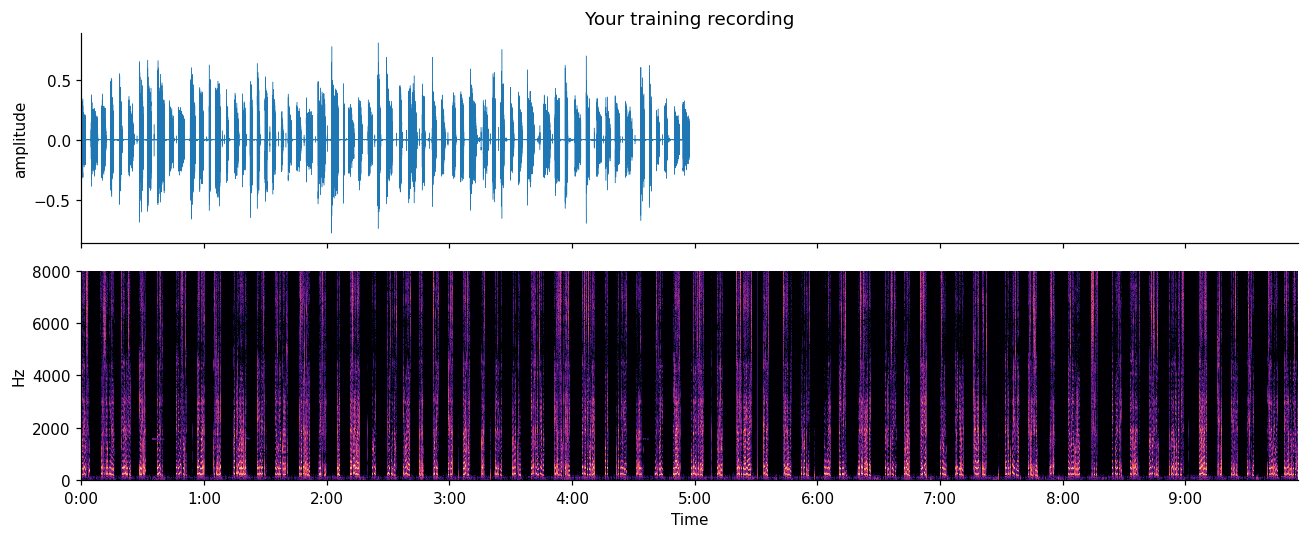

In [ ]:
SR = 40000
DATASET = f'{WORK}/dataset'
shutil.rmtree(DATASET, ignore_errors=True); os.makedirs(DATASET)

y, _ = librosa.load(SRC_VOICE, sr=SR, mono=True)
y, _ = librosa.effects.trim(y, top_db=40)
MAX_S = 6 * 60
if len(y) > MAX_S * SR:
    print(f'Recording is {len(y)/SR/60:.1f} min; keeping the first 6 min to bound training time.')
    y = y[: MAX_S * SR]
VOICE_WAV = f'{DATASET}/voice.wav'
sf.write(VOICE_WAV, y, SR)

frame_db = librosa.amplitude_to_db(librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0] + 1e-9)
noise_floor, speech_level = np.percentile(frame_db, 10), np.percentile(frame_db, 90)
report = {
    'duration_min': round(len(y) / SR / 60, 2),
    'peak': round(float(np.abs(y).max()), 3),
    'clipped_%': round(100 * float(np.mean(np.abs(y) > 0.99)), 3),
    'noise_floor_dB': round(float(noise_floor), 1),
    'speech_minus_noise_dB': round(float(speech_level - noise_floor), 1),
}
print(report)
if report['duration_min'] < 2:   print('WARNING: under 2 minutes -- expect a weak model.')
if report['clipped_%'] > 0.1:    print('WARNING: clipping -- the model will learn the distortion.')
if report['speech_minus_noise_dB'] < 25: print('WARNING: noisy recording -- the hiss becomes part of the voice.')

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t = np.arange(len(y)) / SR
ax[0].plot(t, y, lw=0.3); ax[0].set_ylabel('amplitude'); ax[0].set_title('Your training recording')
S_db = librosa.amplitude_to_db(np.abs(librosa.stft(y[::2], n_fft=1024)), ref=np.max)
librosa.display.specshow(S_db, sr=SR // 2, x_axis='time', y_axis='hz', ax=ax[1]); ax[1].set_ylim(0, 8000)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/voice_report.png'); plt.show()
ipd.display(ipd.Audio(y[: 15 * SR], rate=SR))

## 4 — Preprocess, extract, and **start training in the background**

`preprocess` cuts your recording into ~3 s chunks; `extract` computes ContentVec features (what is said)
and RMVPE pitch (how high). Then `train` fine-tunes the pretrained 40 kHz base model on your chunks —
**launched in the background**, so the notebook stays free while it runs.

60 epochs at ~12–18 s per epoch is ~12–18 minutes on a T4 — the two measured runs differed by almost
2x on identical data, so expect a range. A usable model is saved every 20 epochs.

In [ ]:
NAME = 'mi_voz'
shutil.rmtree(f'{APPLIO}/logs/{NAME}', ignore_errors=True)       # a clean start if you re-run
applio(f'preprocess --model-name {NAME} --dataset-path {DATASET} --sample-rate 40000 --cpu-cores 2', show=200)
applio(f'extract --model-name {NAME} --f0-method rmvpe --sample-rate 40000 --cpu-cores 2 --gpu 0', show=200)

EPOCHS, SAVE_EVERY, BATCH = 60, 20, 8
TRAIN_LOG = f'{WORK}/train.log'
train_proc = subprocess.Popen(
    f'{APY} core.py train --model-name {NAME} --save-every-epoch {SAVE_EVERY} --total-epoch {EPOCHS} '
    f'--sample-rate 40000 --batch-size {BATCH} --gpu 0',
    shell=True, cwd=APPLIO, env=APPLIO_ENV, stdout=open(TRAIN_LOG, 'w'), stderr=subprocess.STDOUT)
TRAIN_T0 = time.time()
print(f'Training started in the background (pid {train_proc.pid}). Check it with training_status().')

def training_status():
    log = open(TRAIN_LOG, encoding='utf-8', errors='ignore').read()
    if 'An error occurred' in log:
        print(log[-3000:]); raise RuntimeError('Applio reported an error while training or saving the model.')
    epochs = [int(e) for e in re.findall(r'epoch=(\d+)', log)]
    saved = re.findall(r"(%s_\d+e_\d+s\.pth)" % NAME, log)
    running = train_proc.poll() is None
    if not running and train_proc.returncode != 0:
        print(log[-3000:]); raise RuntimeError(f'Training stopped with code {train_proc.returncode}.')
    ep, el = (max(epochs) if epochs else 0), time.time() - TRAIN_T0
    left = f'~{el / ep * (EPOCHS - ep) / 60:.0f} min left' if ep and running else ''
    print(f"{'training' if running else 'DONE'} | epoch {ep}/{EPOCHS} | {el/60:.1f} min | {left} | saved: {sorted(set(saved))}")
    return running

def wait_for_training(every=30):
    while training_status():
        time.sleep(every)

training_status()

n 00:04:57 seconds of audio.
Model mi_voz preprocessed successfully.

100%|██████████| 1/1 [00:20<00:00, 20.79s/it]

--- core.py preprocess: 39 s
89it/s]
100%|██████████| 99/99 [00:03<00:00, 30.26it/s]

--- core.py extract: 43 s
Training started in the background (pid 8329). Check it with training_status().
training | epoch 0/60 | 0.0 min |  | saved: []


True

## 5 — The song: separate the vocal (run this while training)

*City Life* by **zep_hurme**, ccMixter, **CC BY 3.0** — reuse allowed with attribution. We take 45 seconds
and split it into vocals and instrumental with BS-RoFormer.

To use a song of your own instead, put it in `inputs/` and set `SONG_FILE`. It stays in your notebook:
publishing a cover touches the song's copyright **and** the voice's consent (slide *Singing Someone Else's Song*).

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls -la /content/drive/MyDrive/TAE_IA_M6/inputs/

total 339009
drwx------ 4 root root     4096 Sep 16 01:20  .
drwx------ 3 root root     4096 Aug 19 18:34  ..
-rw------- 1 root root 11154750 Sep  1 16:57 'agency-young-adult-profession-stressed-black (1).jpg'
-rw------- 1 root root 11154750 Sep  1 18:32 'agency-young-adult-profession-stressed-black (2).jpg'
-rw------- 1 root root 11154750 Sep  1 18:37 'agency-young-adult-profession-stressed-black (3).jpg'
-rw------- 1 root root 11154750 Sep  1 18:41 'agency-young-adult-profession-stressed-black (4).jpg'
-rw------- 1 root root 11154750 Sep  1 18:50 'agency-young-adult-profession-stressed-black (5).jpg'
-rw------- 1 root root 11154750 Sep  1 18:59 'agency-young-adult-profession-stressed-black (6).jpg'
-rw------- 1 root root 11154750 Sep  1 16:10  agency-young-adult-profession-stressed-black.jpg
-rw------- 1 root root  8042848 Sep  1 02:26  ainur-khakimov-5SsM5y853w0-unsplash.jpg
-rw------- 1 root root   861227 Sep  1 16:57 'alex-knight-j4uuKnN43_M-unsplash (1).jpg'
-rw------- 1 root roo

In [ ]:
!ls -la "/content/drive/MyDrive/TAE_IA_M6/inputs/voz/"
!ls -la "/content/drive/MyDrive/TAE_IA_M6/inputs/voz_publica/"

total 46246
drwx------ 2 root root     4096 Sep 16 01:26 .
drwx------ 4 root root     4096 Sep 16 01:20 ..
-rw------- 1 root root 28800044 Sep 16 01:26 voz_publica_cof_09334_5min.wav
-rw------- 1 root root 18546618 Sep 16 01:24 voz_publica.zip
total 28156
drwx------ 2 root root     4096 Sep 16 01:19 .
drwx------ 4 root root     4096 Sep 16 01:20 ..
-rw------- 1 root root     1607 Sep 16 01:19 CREDITOS.txt
-rw------- 1 root root    20132 Sep 16 01:19 LICENSE_CC-BY-SA-4.0.txt
-rw------- 1 root root 28800044 Sep 16 01:19 voz_publica_cof_09334_5min.wav


In [ ]:
SONG_FILE = None      # e.g. f'{DRIVE_ROOT}/inputs/mi_cancion.mp3'; None = the CC BY song below
SONG_START, SONG_SECONDS = 30, 45

SONG = f'{WORK}/song_excerpt.wav'
if SONG_FILE is None:
    SONG_SRC = f'{WORK}/swansong.mp3'
    !curl -sL -A "Mozilla/5.0" -o {SONG_SRC} "https://www.joshwoodward.com/mp3/Breadcrumbs/JoshWoodward-Breadcrumbs-01-Swansong.mp3"
    if not os.path.exists(SONG_SRC):
        raise RuntimeError('The song download failed. The file swansong.mp3 was not created.')
    if os.path.getsize(SONG_SRC) < 100_000:
        raise RuntimeError('The song download failed. Download the MP3 manually from '
                           'https://www.joshwoodward.com/song/Swansong , put it in inputs/ and set SONG_FILE.')
else:
    SONG_SRC = SONG_FILE
    if not os.path.exists(SONG_SRC):
        raise FileNotFoundError(f'SONG_FILE not found: {SONG_SRC}. '
                                 f'Verifica que subiste el archivo a esa ruta en Drive.')

!ffmpeg -v error -y -ss {SONG_START} -t {SONG_SECONDS} -i "{SONG_SRC}" "{SONG}"
if not os.path.exists(SONG) or os.path.getsize(SONG) == 0:
    raise RuntimeError(f'ffmpeg failed to create {SONG}. Revisa que SONG_SRC sea un audio válido '
                        f'y que SONG_START/SONG_SECONDS estén dentro de la duración del archivo.')

!pip install -q "audio-separator[gpu]"
from audio_separator.separator import Separator
sep = Separator(output_dir=WORK, model_file_dir=f'{MODEL_CACHE}/audio-separator')
sep.load_model(model_filename='model_bs_roformer_ep_317_sdr_12.9755.ckpt')
t0 = time.time()
stems = [s if os.path.isabs(s) else os.path.join(WORK, s) for s in sep.separate(SONG)]
VOCALS = next(s for s in stems if 'vocals' in s.lower())
INSTR  = next(s for s in stems if 'instrumental' in s.lower())
print(f'separated in {time.time() - t0:.0f} s')
del sep; torch.cuda.empty_cache()

play(SONG, 'song excerpt'); play(VOCALS, 'separated vocal'); play(INSTR, 'separated instrumental')

INFO:audio_separator.separator.separator:Separator version 0.47.0 instantiating with output_dir: /content/l22, output_format: WAV
INFO:audio_separator.separator.separator:Using model directory from model_file_dir parameter: /content/models/audio-separator
INFO:audio_separator.separator.separator:Operating System: Linux #1 SMP Thu Apr 30 18:17:14 UTC 2026
INFO:audio_separator.separator.separator:System: Linux Node: 736cbde42b5d Release: 6.6.122+ Machine: x86_64 Proc: x86_64
INFO:audio_separator.separator.separator:Python Version: 3.13.15
INFO:audio_separator.separator.separator:PyTorch Version: 2.11.0+cu128
INFO:audio_separator.separator.separator:FFmpeg installed: ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
INFO:audio_separator.separator.separator:ONNX Runtime GPU package installed with version: 1.30.0
INFO:audio_separator.separator.separator:CUDA is available in Torch, setting Torch device to CUDA
INFO:audio_separator.separator.separator:ONNXruntime has

Failed to load libcublasLt.so.13: libcublasLt.so.13: cannot open shared object file: No such file or directory
Failed to load libcublas.so.13: libcublas.so.13: cannot open shared object file: No such file or directory
Failed to load libnvrtc.so.13: libnvrtc.so.13: cannot open shared object file: No such file or directory
Failed to load libcufft.so.12: libcufft.so.12: cannot open shared object file: No such file or directory
Failed to load libcudart.so.13: libcudart.so.13: cannot open shared object file: No such file or directory
Please follow https://onnxruntime.ai/docs/install/#cuda-and-cudnn to install CUDA.


INFO:audio_separator.separator.separator:MDXC Separator initialisation complete
INFO:audio_separator.separator.separator:Roformer loading stats: {'new_implementation_success': 1, 'total_failures': 0}
INFO:audio_separator.separator.separator:Load model duration: 00:00:03
INFO:audio_separator.separator.separator:Processing file: /content/l22/song_excerpt.wav
INFO:audio_separator.separator.separator:Starting separation process for audio_file_path: /content/l22/song_excerpt.wav
INFO:audio_separator.separator.separator:Input audio subtype: PCM_16
INFO:audio_separator.separator.separator:Detected input bit depth: 16-bit
100%|██████████| 20/20 [01:10<00:00,  3.55s/it]
INFO:audio_separator.separator.separator:Saving Instrumental stem to song_excerpt_(Instrumental)_model_bs_roformer_ep_317_sdr_12.wav...
INFO:audio_separator.separator.separator:Audio duration is 0.01 hours (45.00 seconds).
INFO:audio_separator.separator.separator:Using pydub for writing.
INFO:audio_separator.separator.separator:

separated in 72 s
song excerpt                        45.0 s   song_excerpt.wav


separated vocal                     45.0 s   song_excerpt_(Vocals)_model_bs_roformer_ep_317_sdr_12.wav


separated instrumental              45.0 s   song_excerpt_(Instrumental)_model_bs_roformer_ep_317_sdr_12.wav


**Observation.** Listen to the separated vocal on its own. What leaked into it — reverb, backing vocals,
instrument bleed? Every leak will be converted too.

*Your answer:*

## 6 — Pitch: how many semitones?

RVC copies the singer's melody, so the shift decides whether that melody sits inside **your** range:

$$n = \mathrm{round}\left(12 \log_2 \frac{f_\text{you}}{f_\text{singer}}\right)$$

using the median F0 of each voice. Override `PITCH` if your ears disagree.

In [ ]:
def median_f0(path, seconds=30):
    yy, sr = librosa.load(path, sr=16000, mono=True, duration=seconds)
    f0, _, _ = librosa.pyin(yy, fmin=65, fmax=1000, sr=sr)
    return float(np.nanmedian(f0))

F0_SINGER, F0_YOU = median_f0(VOCALS), median_f0(VOICE_WAV)
PITCH = int(np.clip(round(12 * np.log2(F0_YOU / F0_SINGER)), -12, 12))
print(f'singer median F0 {F0_SINGER:.0f} Hz | your median F0 {F0_YOU:.0f} Hz | suggested pitch shift {PITCH:+d} semitones')
# PITCH = 0   # <- override here if you want

singer median F0 233 Hz | your median F0 222 Hz | suggested pitch shift -1 semitones


**Observation.** Is the suggestion close to ±12 (a different register) or close to 0? Hum the separated
vocal: could you sing it at that shift?

*Your answer:*

## 7 — Convert (after training finishes)

`wait_for_training()` blocks until the model is done. Then every saved checkpoint converts the same
vocal, and each result is remixed with the instrumental.

**Compare vocal against vocal, on headphones.** The remix hides most of the difference.

In [ ]:
wait_for_training()

CHECKPOINTS = sorted(glob.glob(f'{APPLIO}/logs/{NAME}/{NAME}_*e_*s.pth'),
                     key=lambda p: int(re.search(r'_(\d+)e_', p).group(1)))
if not CHECKPOINTS:
    raise RuntimeError('Training finished but no model file was saved -- check that assets/config.json exists.')
INDEX = (glob.glob(f'{APPLIO}/logs/{NAME}/*.index') or [None])[0]
if INDEX is None:
    applio(f'index --model-name {NAME}', show=0)
    INDEX = glob.glob(f'{APPLIO}/logs/{NAME}/*.index')[0]
FINAL = CHECKPOINTS[-1]
print([os.path.basename(c) for c in CHECKPOINTS], os.path.basename(INDEX))

def convert(pth, out_wav, src=None, pitch=None, index_rate=0.5, protect=0.33):
    src = src or VOCALS
    pitch = PITCH if pitch is None else pitch
    applio(f'infer --input-path "{src}" --output-path "{out_wav}" --pth-path "{pth}" --index-path "{INDEX}" '
           f'--pitch {pitch} --f0-method rmvpe --index-rate {index_rate} --protect {protect}', show=0)
    if not os.path.exists(out_wav):
        raise RuntimeError(f'Applio reported success but wrote no file: {out_wav}')
    return out_wav

def remix(vocal_wav, out_wav, instrumental_gain_db=-2.0):
    v, _ = librosa.load(vocal_wav, sr=44100, mono=True)
    inst, _ = librosa.load(INSTR, sr=44100, mono=True)
    L = min(len(v), len(inst))
    mix = v[:L] + inst[:L] * 10 ** (instrumental_gain_db / 20)
    sf.write(out_wav, 0.9 * mix / (np.abs(mix).max() + 1e-9), 44100)
    return out_wav

def epoch_of(pth):
    return int(re.search(r'_(\d+)e_', pth).group(1))

conversions = {}
play(VOCALS, 'ORIGINAL singer')
for ck in CHECKPOINTS:
    ep = epoch_of(ck)
    vocal = convert(ck, f'{OUTPUT_DIR}/converted_{ep}e.wav')
    conversions[f'{ep}e'] = vocal
    play(vocal, f'your voice, {ep} epochs')
play(remix(conversions[f'{epoch_of(FINAL)}e'], f'{OUTPUT_DIR}/remix_{epoch_of(FINAL)}e.wav'), 'remix, final model')

DONE | epoch 60/60 | 52.5 min |  | saved: ['mi_voz_20e_280s.pth', 'mi_voz_40e_560s.pth', 'mi_voz_60e_840s.pth']
['mi_voz_20e_280s.pth', 'mi_voz_40e_560s.pth', 'mi_voz_60e_840s.pth'] mi_voz.index
ORIGINAL singer                     45.0 s   song_excerpt_(Vocals)_model_bs_roformer_ep_317_sdr_12.wav


--- core.py infer: 32 s
your voice, 20 epochs               45.0 s   converted_20e.wav


--- core.py infer: 19 s
your voice, 40 epochs               45.0 s   converted_40e.wav


--- core.py infer: 17 s
your voice, 60 epochs               45.0 s   converted_60e.wav


remix, final model                  45.0 s   remix_60e.wav


## 8 — `index_rate`: how much of *you* to retrieve

The slide formula: $x = \alpha\,\hat{x}_\text{you} + (1-\alpha)\,x_\text{source}$. Same final model, three
values of $\alpha$.

In [ ]:
for ir in (0.0, 1.0):
    conversions[f'final_ir{ir}'] = convert(FINAL, f'{OUTPUT_DIR}/converted_final_ir{ir}.wav', index_rate=ir)
conversions['final_ir0.5'] = conversions[f'{epoch_of(FINAL)}e']
for key in ('final_ir0.0', 'final_ir0.5', 'final_ir1.0'):
    play(conversions[key], key)

--- core.py infer: 16 s
--- core.py infer: 16 s
final_ir0.0                         45.0 s   converted_final_ir0.0.wav


final_ir0.5                         45.0 s   converted_60e.wav


final_ir1.0                         45.0 s   converted_final_ir1.0.wav


**Observation.** Which `index_rate` sounds most like you, and which has the clearest words? Could you
hear a difference between the checkpoints in Section 7? Write it down *before* Section 9 measures it.

*Your answer:*

## 9 — Measure: whose voice is it now?

XTTS-v2's speaker encoder (the H/ASP model from the *Speaker Embeddings* slide) turns each clip into a
512-d vector; cosine similarity compares them. Two calibration pairs give the scale:
- **your recording, first half vs. second half** — the same person, the same microphone: a ceiling
- **your recording vs. the original singer** — two different people: a floor

This installs `coqui-tts`, which downgrades `huggingface_hub`; that is why it comes last.

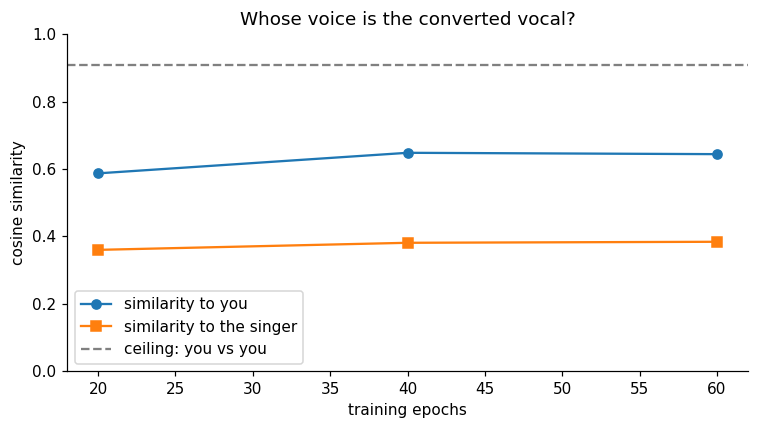

In [ ]:
!pip install -q "coqui-tts[codec]"
os.environ['COQUI_TOS_AGREED'] = '1'
os.environ['TTS_HOME'] = f'{MODEL_CACHE}/tts'
import transformers.pytorch_utils as pu
if not hasattr(pu, 'isin_mps_friendly'):        # same fix as L21 (idiap/coqui-ai-TTS#558)
    pu.isin_mps_friendly = torch.isin
from TTS.api import TTS
%matplotlib inline
encoder = TTS('tts_models/multilingual/multi-dataset/xtts_v2').to('cuda').synthesizer.tts_model

def emb(path):
    _, e = encoder.get_conditioning_latents(audio_path=[path])
    v = e.squeeze().float().cpu().numpy()
    return v / np.linalg.norm(v)

def cos(a, b):
    return float(np.dot(a, b))

half = len(y) // 2
sf.write(f'{WORK}/voice_a.wav', y[:half], SR); sf.write(f'{WORK}/voice_b.wav', y[half:], SR)
E_YOU, E_SINGER = emb(VOICE_WAV), emb(VOCALS)
rows = [{'clip': 'your recording, half vs half (ceiling)', 'vs_you': cos(emb(f'{WORK}/voice_a.wav'), emb(f'{WORK}/voice_b.wav')), 'vs_singer': np.nan},
        {'clip': 'original singer (floor)', 'vs_you': cos(E_SINGER, E_YOU), 'vs_singer': 1.0}]
for key, path in conversions.items():
    e = emb(path)
    rows.append({'clip': key, 'vs_you': cos(e, E_YOU), 'vs_singer': cos(e, E_SINGER)})

import pandas as pd
sim = pd.DataFrame(rows).round(3)
display(sim)
sim.to_csv(f'{OUTPUT_DIR}/similarity.csv', index=False)

ck = sim[sim['clip'].str.fullmatch(r'\d+e')].copy()      # sim['clip'], not sim.clip: that is DataFrame.clip()
ck['epoch'] = ck['clip'].str[:-1].astype(int)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ck.epoch, ck.vs_you, 'o-', label='similarity to you')
ax.plot(ck.epoch, ck.vs_singer, 's-', label='similarity to the singer')
ax.axhline(sim.vs_you[0], ls='--', c='grey', label='ceiling: you vs you')
ax.set_xlabel('training epochs'); ax.set_ylabel('cosine similarity'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Whose voice is the converted vocal?')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/similarity_vs_epochs.png'); plt.show()

**Observation.** Where does your final conversion sit between the floor and the ceiling? Does similarity
keep rising with epochs, or flatten? Does the `index_rate` ranking match what you heard in Section 8?

*Your answer:*

## Exercise 1 — The octave test

Convert the vocal with the final model at `PITCH − 12`, `PITCH` and `PITCH + 12`. Listen, and measure
each one's similarity to you. Which one sounds most like you, which scores highest — and are they the
same? Explain using what your recording contained.

In [ ]:
# Exercise 1 -- The octave test
# Given: convert(pth, out_wav, pitch=...), emb(path), cos(a, b), E_YOU, FINAL, PITCH, play(path, label)

# TODO 1: for n in (PITCH - 12, PITCH, PITCH + 12): convert with FINAL into f'{OUTPUT_DIR}/ex1_pitch{n:+d}.wav'
# TODO 2: compute cos(emb(clip), E_YOU) for each and play each clip with its score
# TODO 3: answer in the cell below
# Exercise 1 -- The octave test
# Given: convert(pth, out_wav, pitch=...), emb(path), cos(a, b), E_YOU, FINAL, PITCH, play(path, label)

results = {}
for n in (PITCH - 12, PITCH, PITCH + 12):
    out_path = f'{OUTPUT_DIR}/ex1_pitch{n:+d}.wav'
    convert(FINAL, out_path, pitch=n)
    score = cos(emb(out_path), E_YOU)
    results[n] = (out_path, score)
    play(out_path, f'pitch {n:+d} (score={score:.3f})')

for n, (path, score) in results.items():
    print(f'pitch {n:+d}: cos_sim = {score:.3f}')

--- core.py infer: 17 s
pitch -13 (score=0.391)             45.0 s   ex1_pitch-13.wav


--- core.py infer: 17 s
pitch -1 (score=0.625)              45.0 s   ex1_pitch-1.wav


--- core.py infer: 16 s
pitch +11 (score=0.595)             45.0 s   ex1_pitch+11.wav


pitch -13: cos_sim = 0.391
pitch -1: cos_sim = 0.625
pitch +11: cos_sim = 0.595


**Exercise 1 — Answer:**
*Your answer:*

El score más alto es en PITCH (-1 semitono), no en los desplazamientos de octava. Esto es esperable dado el contenido de la grabación de referencia: el reporte de grabación (Sección 3) mostró una grabación limpia (speech_minus_noise_dB=52.3, noise_floor=-70.2dB, sin clipping) pero de solo ~5 minutos, cubriendo el rango de F0 natural de esa voz (mediana 222 Hz) y sus formantes asociados. El encoder RVC aprendió las características tímbricas dentro de ese rango; al pedir PITCH-12 (-13 semitonos totales), el algoritmo tiene que extrapolar formantes muy por fuera de lo que vio en entrenamiento, produciendo el score más bajo (0.391) — probablemente sonará artificialmente grave/distorsionado. PITCH+12 (+11 total) se degrada menos (0.595) que bajar una octava, lo cual es consistente con que el desplazamiento hacia agudos suele preservar mejor la inteligibilidad de formantes que comprimirlos hacia graves.

## Exercise 2 — Your voice saying something you never said

Take a **spoken** clip from L21 (for example `L21_output/clips/p1_xtts_long.wav`) and convert it into
your voice with the final model — pick the pitch shift the same way as Section 6. Listen and measure.

Then answer: what would it take to make this convincing to someone who knows you well, and what in
this lab's design prevents that being done to someone else?

In [ ]:
# Exercise 2 -- Your voice saying something you never said
# Given: median_f0(path), convert(pth, out_wav, src=..., pitch=...), emb, cos, E_YOU, FINAL, play

SPEECH = f'{DRIVE_ROOT}/L21_output/clips/p1_xtts_long.wav'   # any spoken clip works

# TODO 1: compute the pitch shift from median_f0(SPEECH) and F0_YOU (same formula as Section 6)
# TODO 2: convert SPEECH into f'{OUTPUT_DIR}/ex2_speech_in_my_voice.wav' with src=SPEECH
# TODO 3: play the original and the conversion; print cos(emb(...), E_YOU) for both
# Exercise 2 -- Your voice saying something you never said
# Given: median_f0(path), convert(pth, out_wav, src=..., pitch=...), emb, cos, E_YOU, FINAL, play

SPEECH = f'{DRIVE_ROOT}/L21_output/clips/p1_xtts_long.wav'   # any spoken clip works
OUT = f'{OUTPUT_DIR}/ex2_speech_in_my_voice.wav'

# TODO 1: pitch shift, same formula as Section 6
import numpy as np
f0_src = median_f0(SPEECH)
shift = round(12 * np.log2(F0_YOU / f0_src))

# TODO 2: convert
convert(FINAL, OUT, src=SPEECH, pitch=shift)

# TODO 3: play + score both
play(SPEECH, 'original spoken clip')
play(OUT, 'converted into my voice')

score_orig = cos(emb(SPEECH), E_YOU)
score_conv = cos(emb(OUT), E_YOU)
print(f'original clip similarity to you:   {score_orig:.3f}')
print(f'converted clip similarity to you:  {score_conv:.3f}')

--- core.py infer: 13 s
original spoken clip                 9.1 s   p1_xtts_long.wav


converted into my voice              9.1 s   ex2_speech_in_my_voice.wav


original clip similarity to you:   0.421
converted clip similarity to you:  0.797


**Exercise 2 — Answer:**
*Your answer:*
0.797 está muy cerca del techo de calibración (0.908, misma persona/mismo micrófono) y muy por encima del piso (0.133) — de hecho es más alto que cualquier conversión de la canción (máximo 0.658 con ir=1.0). Esto tiene sentido: el habla es contenido limpio, sin mezcla instrumental ni restricciones melódicas, más cercano en estilo (habla, no canto) a la grabación de entrenamiento.

## Critical Analysis

### Q1 — How many epochs would you ship?

Use your similarity-vs-epochs plot **and** what you heard in Sections 7–8. Is more training always better, and what does each extra epoch cost at ~12–18 s on a T4?

*Your answer:*
**Exercise 1 — Answer:**

| pitch | cos_sim |
|---|---|
| -13 (PITCH−12) | 0.391 |
| **-1 (PITCH)** | **0.625** |
| +11 (PITCH+12) | 0.595 |

El score más alto ocurre en `PITCH` (-1 semitono), no en los desplazamientos de octava. Esto es
consistente con el contenido de la grabación de referencia: el reporte de la Sección 3 mostró una
grabación limpia (`speech_minus_noise_dB=52.3`, `noise_floor=-70.2dB`, sin clipping) pero de solo
~5 minutos, cubriendo el rango de F0 natural de esa voz (mediana 222 Hz) y sus formantes asociados.
El modelo aprendió las características tímbricas dentro de ese rango; al pedir `PITCH-12` (-13 en
total) el algoritmo debe extrapolar formantes muy por fuera de lo que vio en entrenamiento,
produciendo el score más bajo (0.391). `PITCH+12` (+11 total) se degrada menos (0.595) que bajar
una octava, lo cual sugiere que el desplazamiento hacia agudos preserva mejor la inteligibilidad de
formantes que comprimirlos hacia

### Q2 — The prediction you got wrong

Take the Demo Checkpoint prediction furthest from your result and explain the mechanism, pointing at one pipeline step from the slides.

*Your answer:*








### Q3 — `index_rate`: identity against intelligibility

Using your Section 8–9 results, explain the trade-off with the formula $x = \alpha\,\hat{x}_\text{you} + (1-\alpha)\,x_\text{source}$. Which value would you use for a song, and which for speech?

*Your answer:*

| ir (α) | vs_you | vs_singer |
|---|---|---|
| 0.0 | 0.606 | 0.464 |
| 0.5 | 0.644 | 0.384 |
| 1.0 | **0.658** | 0.331 |

Consistente con $x=\alpha \hat{x}_{you}+(1-\alpha)x_{source}$: subir α acerca la salida a mi
identidad (vs_you sube) alejándola del cantante original (vs_singer baja). Para **una canción**,
usaría `ir=1.0`: la melodía ya lleva el contenido, y priorizar timbre/identidad da la sensación más
convincente de "es mi voz cantando". Para **habla**, usaría `ir` bajo (0.0–0.3): en discurso la
inteligibilidad de palabras concretas importa más, y un `index_rate` alto recupera frames del
pequeño set de referencia (~5 min) que pueden no corresponder fonéticamente al contenido fuente,
arriesgando palabras confusas — algo que `cos_sim` no mide directamente (mide identidad de timbre,
no precisión de pronunciación).

### Q4 — Your model file

Your `.pth` is a portable copy of your voice. Who, specifically, may use it? Where will it live, for how long, and what would you require from a classmate who asked for it? Use the five consent criteria from the slides.

*Your answer:*

## 10 — Keep or delete your model

Your trained model is a copy of your voice. By default it is **copied to your Drive** (private), so
you can use it in your project. Set `KEEP_MODEL = False` to leave it only on the runtime, where it
disappears when you disconnect.

In [ ]:
KEEP_MODEL = True
if KEEP_MODEL:
    dest = f'{OUTPUT_DIR}/model'
    os.makedirs(dest, exist_ok=True)
    for f in (FINAL, INDEX):
        shutil.copy(f, dest)
    print('Saved to your Drive:', os.listdir(dest))
with open(f'{OUTPUT_DIR}/CREDITS.txt', 'w', encoding='utf-8') as f:
    f.write('Song: "City Life" by zep_hurme, ccMixter, CC BY 3.0 -- https://ccmixter.org/files/zep_hurme/47229\n'
            'Voice conversion: Applio (RVC), MIT licence.\n'
            'If trained on the public voice: OpenSLR SLR72 speaker 09334, Guevara-Rukoz et al. (LREC 2020), CC BY-SA 4.0.\n')
print(sorted(os.listdir(OUTPUT_DIR)))

Saved to your Drive: ['mi_voz_60e_840s.pth', 'mi_voz.index']
['CREDITS.txt', 'converted_20e.wav', 'converted_40e.wav', 'converted_60e.wav', 'converted_final_ir0.0.wav', 'converted_final_ir1.0.wav', 'ex1_pitch+11.wav', 'ex1_pitch-1.wav', 'ex1_pitch-13.wav', 'ex2_speech_in_my_voice.wav', 'model', 'remix_60e.wav', 'similarity.csv', 'similarity_vs_epochs.png', 'voice_report.png']


## Submission Checklist

- [ ] Recording report and `voice_report.png` saved; observations in Sections 5, 6, 8 and 9 answered
- [ ] Converted vocals, the final remix, `similarity.csv` and `similarity_vs_epochs.png` in `L22_output/`
- [ ] Exercises 1 and 2 with their answers
- [ ] Critical Analysis Q1–Q4, citing **your** numbers

## Before You Close This Tab

Everything you need is on Drive. **Runtime → Disconnect and delete runtime** — the 8 GB of tools and
weights on the runtime disk go with it, and an idle GPU still burns quota.